## Лаборатона робота №2

**Виконали:**
- Сачек Вледислава КА-31
- Богданова Олександра КА-32
- Плахтій Злата КА-32

**Хід роботи:**

1. Завантажити простий набiр зображень згiдно з варiантом.
2. Виконати пiдготовку даних для навчання - за необхiдностi, залежно вiд вхiдного набору. Наприклад, нормалiзувати данi тощо.
3. За необхiдностi розбити данi на навчальну i перевiрочну множини у спiввiдношеннi 80%: 20%. Звернути увагу, що завантаженi данi вже можуть бути розбитi на навчальну i перевiрочну множини.
4. Побудувати базову мережу прямого розповс
юдження сигналу з єдиним скритим шаром i output шаром softmax. Для створення моделi реалiзувати власний клас, який наслiдує клас object. Ваги iнiцiалiзувати невеликими випадковими значеннями, якi нормально розподiленi з нульовим середнiм та малою дисперсiєю.
5. Реалiзувати алгоритм зворотного розповсюдження помилки (back propagation).
6. Функцiєю втрат задати перехресну ентропiю.
7. Налаштувати ваги побудованої мережi реалiзованим алгоритмом back propagation.
8. Побудувати кiлька альтернативних мереж MLP з кiлькома скритими шарами ReLU або tanh. Налаштувати їх ваги реалiзованим алгоритмом back propagation.
9. Для кожної моделi побудувати:
- графiки змiни значень функцiї втрат на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделi, тобто залежно вiд кiлькостi епох,
- графiки змiни показника accuracy на тренувальнiй i перевiрочнiй
множинах по мiрi навчання моделi.
10. Пiдiбрати значення гiперпараметра швидкостi навчання.
11. Обрати для нейронiв скритих шарiв рiзнi функцiї активацiї: LeakyReLU, Parametric LeakyReLU, ELU. Спробувати з’ясувати чи впливає вибiр
функцiї активацiї на:
- час навчання мережi,
- якiсть роботи мережi (фiнальне значення accuracy) на перевiрочнiй множинi,
- час надання прогнозу мережею.
12. Вiдобразити кiлька зображень, невiрно класифiкованих моделлю.

**Варіант 2**
Набір даних: Fashion MNIST, kaggle.com 

### Імпорт бібліотек і завантаження датасету Fashion MNIST

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Fashion MNIST - датасет з 70 000 зображень предметів одягу (60 000 для навчання, 10 000 для тесту). Кожне зображення — 28×28 пікселів у градаціях сірого, належить одному з 10 класів: футболка, штани, светр, сукня, пальто, сандалі, сорочка, кросівки, сумка, черевик.

Використовуємо цей датасет у форматі CSV, адже його можна прочитати без допомоги додаткових бібліотек.

**Структура CSV:**
1-й стовпець "label" - клас (0-9),
решта 784 стовці - пікселі зображення 28х28, розгорнуті в рядок.

Спершу відокремлюємо мітки від пікселів. Потім нормалізуємо пікселі та подаємо мережу у вигляді векторів розміром 754.

Train: (60000, 784) | Test: (10000, 784)
Діапазон пікселів: [0, 255]


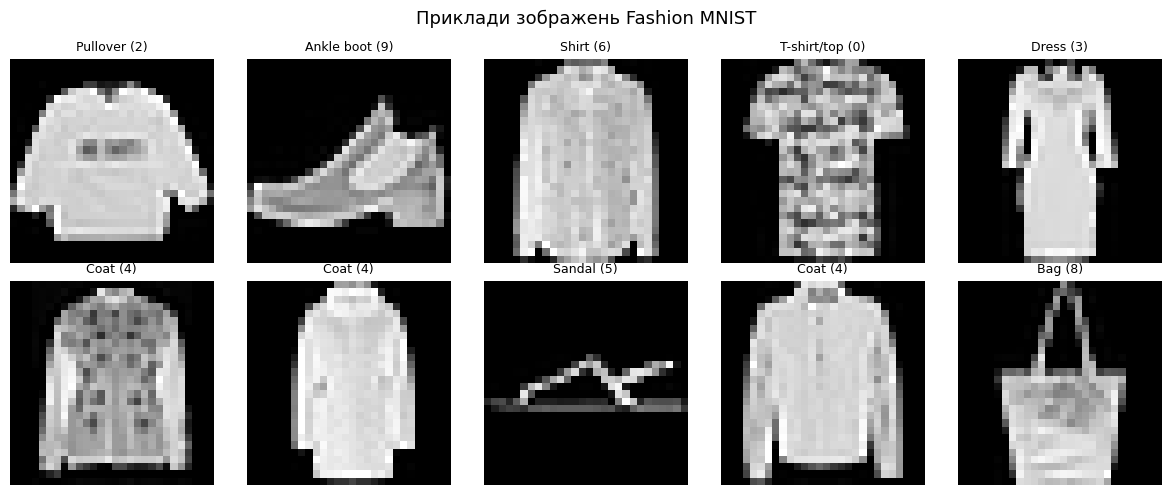

In [11]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')

y_train_raw = train_df['label'].values
X_train_raw = train_df.drop('label', axis=1).values  # (60000, 784)

y_test_raw  = test_df['label'].values
X_test_raw  = test_df.drop('label', axis=1).values   # (10000, 784)

# Повертаємо пікселі у формат зображень для візуалізації
X_train_imgs = X_train_raw.reshape(-1, 28, 28)
X_test_imgs  = X_test_raw.reshape(-1, 28, 28)

print(f"Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")
print(f"Діапазон пікселів: [{X_train_raw.min()}, {X_train_raw.max()}]")

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_imgs[i], cmap='gray')
    ax.set_title(f"{CLASS_NAMES[y_train_raw[i]]} ({y_train_raw[i]})", fontsize=9)
    ax.axis('off')
plt.suptitle('Приклади зображень Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()

> Бачимо кількість завантажених тренувального та перевірочного наборів. Дані ще не нормалізовані.

> На графіку показано 10 випадкових зображень з тренувального набору, над кожним - назва класу та його номер.

### Нормалізація 

Нормалізуємо пікселі: [0, 255] → [0.0, 1.0], аби уникнути нестабільності навчання через великі значення пікселів. 
Ділимо на максимальне значення пікселя - 255.0.

In [12]:
X_train_norm = X_train_raw.astype(np.float64) / 255.0  # (60000, 784)
X_test_norm  = X_test_raw.astype(np.float64)  / 255.0  # (10000, 784)

print(f"X_train: {X_train_norm.shape} | діапазон [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"X_test:  {X_test_norm.shape}  | діапазон [{X_test_norm.min():.1f}, {X_test_norm.max():.1f}]")

X_train: (60000, 784) | діапазон [0.0, 1.0]
X_test:  (10000, 784)  | діапазон [0.0, 1.0]


> Дані нормалізовано.

### Розбиття тренувального набору на train/val

Датасет вже містить окремий тестовий набір, тому розбиваємо лише тренувальний. Також перемішуємо індекси для рівномірного розподілу класів за допомогою np.random.permutation.


Train: 48000 | Val: 12000 | Test: 10000


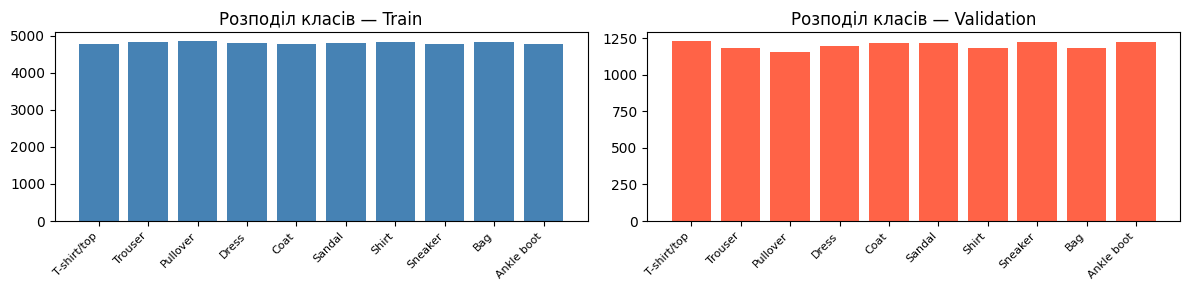

In [13]:
np.random.seed(42)

n_total   = X_train_norm.shape[0]       # 60 000
n_train   = int(n_total * 0.8)          # 48 000
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:]

X_train = X_train_norm[train_idx]       # (48000, 784)
y_train = y_train_raw[train_idx]        # (48000,)
X_val   = X_train_norm[val_idx]         # (12000, 784)
y_val   = y_train_raw[val_idx]          # (12000,)
X_test  = X_test_norm                   # (10000, 784)
y_test  = y_test_raw                    # (10000,)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(range(10), np.bincount(y_train), color='steelblue')
axes[0].set_title('Розподіл класів — Train')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].bar(range(10), np.bincount(y_val), color='tomato')
axes[1].set_title('Розподіл класів — Validation')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

> Бачимо такий результат розбиття: тренувальний набір - 48000, валідаційна множина - 12000, тестовий - 10000. 

> Гістограми показують розподіл класів після розбиття - стовпці приблизно однакової висоти, що означає рівномірний розподіл усіх 10 класів.

### Функції активації та допоміжні функції

Всі функції активації реалізуємо вручну через numpy. Для кожної функції визначено похідну.

**Допоміжні функції:**
- softmax — активація вихідного шару, перетворює логіти у ймовірності
- cross_entropy_loss — функція втрат 
- one_hot — кодування міток для обчислення втрат

In [17]:
def relu(z):
    # **ReLU:** `f(z) = max(0, z)`
    return np.maximum(0, z)

def relu_deriv(z):
    # `f'(z) = 1` якщо `z > 0`, інакше `0`
    return (z > 0).astype(np.float64)

def tanh_act(z):
    # **Tanh:** `f(z) = tanh(z)`, діапазон `(-1, 1)`
    return np.tanh(z)

def tanh_deriv(z):
    # `f'(z) = 1 - tanh²(z)`
    return 1.0 - np.tanh(z) ** 2

def leaky_relu(z, alpha=0.01):
    # **LeakyReLU:** `f(z) = z` якщо `z > 0`, інакше `alpha*z`
    # Вирішує проблему «мертвих нейронів» ReLU
    return np.where(z > 0, z, alpha * z)

def leaky_relu_deriv(z, alpha=0.01):
    # `f'(z) = 1` якщо `z > 0`, інакше `alpha`
    return np.where(z > 0, 1.0, alpha)

def parametric_relu(z, alpha):
    # **PReLU:** як LeakyReLU, але `alpha` — гіперпараметр
    return np.where(z > 0, z, alpha * z)

def parametric_relu_deriv(z, alpha):
    return np.where(z > 0, 1.0, alpha)

def elu(z, alpha=1.0):
    # **ELU:** `f(z) = z` якщо `z > 0`, інакше `alpha*(e^z - 1)`
    # Від'ємна частина плавна → центрує активації навколо нуля
    return np.where(z > 0, z, alpha * (np.exp(z) - 1))

def elu_deriv(z, alpha=1.0):
    # `f'(z) = 1` якщо `z > 0`, інакше `ELU(z) + alpha`
    return np.where(z > 0, 1.0, elu(z, alpha) + alpha)

def softmax(z):
    # **Softmax:** перетворює логіти у ймовірності (сума = 1), лише для вихідного шару
    # Віднімаємо `max(z)` для числової стабільності
    shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z   = np.exp(shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true_onehot):
    # **Cross-entropy:** `L = -1/N * Σ( y_true * log(y_pred) )`
    # `eps=1e-12` — захист від `log(0)`
    eps = 1e-12
    return -np.sum(y_true_onehot * np.log(y_pred + eps)) / y_pred.shape[0]

def one_hot(y, num_classes=10):
    # Перетворення міток у one-hot: `3 → [0,0,0,1,0,0,0,0,0,0]`
    oh = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    oh[np.arange(y.shape[0]), y] = 1.0
    return oh

### Базова мережа прямого розповсюдження

Реалізуємо клас NeuralNetwork(object) - явне успадкування object.

**Архітектура базової мережі:**
- вхідний шар - 784 нейрони (розмір вектора пікселів),
- єдиний приходваний шар - 128 нейронів з обраною функцією активації,
- вихідний шар - 10 нейронів з активацією softmax по кількості класів.

**Ініціалізація ваг:** нормальний розподіл `N(0, σ²)`
- He `σ = √(2/fan_in)` — для ReLU, LeakyReLU, PReLU, ELU,
- Xavier `σ = √(1/fan_in)` — для tanh,
- Biases ініціалізуються нулями.

**Forward pass** обчислює для кожного шару i:
Z[i] = A[i-1] @ W[i] + b[i] — лінійне перетворення,
A[i] = activation(Z[i]) — нелінійна активація.

Проміжні значення Z і A зберігаються у cache.

In [19]:
class NeuralNetwork(object):

    def __init__(self, layer_sizes, hidden_activation='relu', alpha=0.01):
        # layer_sizes — розміри шарів включно з вхідним та вихідним
        # hidden_activation — активація прихованих шарів
        # alpha — параметр для LeakyReLU / PReLU / ELU
        self.layer_sizes       = layer_sizes
        self.hidden_activation = hidden_activation
        self.alpha             = alpha
        self.num_layers        = len(layer_sizes)

        self.weights, self.biases = [], []
        np.random.seed(42)
        for i in range(self.num_layers - 1):
            fan_in  = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            std = np.sqrt(2.0 / fan_in) if hidden_activation != 'tanh' else np.sqrt(1.0 / fan_in)
            self.weights.append(np.random.normal(0.0, std, size=(fan_in, fan_out)))
            self.biases.append(np.zeros((1, fan_out)))

    def _activate(self, z, is_output=False):
       
        if is_output:return softmax(z)
        if self.hidden_activation == 'relu':return relu(z)
        if self.hidden_activation == 'tanh':return tanh_act(z)
        if self.hidden_activation == 'leaky_relu':return leaky_relu(z, self.alpha)
        if self.hidden_activation == 'parametric_relu':return parametric_relu(z, self.alpha)
        if self.hidden_activation == 'elu':return elu(z, self.alpha)
        raise ValueError(f"Невідома активація: {self.hidden_activation}")
    def _activate_deriv(self, z):
        # Похідна активації прихованого шару 
        if self.hidden_activation == 'relu':return relu_deriv(z)
        if self.hidden_activation == 'tanh':return tanh_deriv(z)
        if self.hidden_activation == 'leaky_relu':return leaky_relu_deriv(z, self.alpha)
        if self.hidden_activation == 'parametric_relu':return parametric_relu_deriv(z, self.alpha)
        if self.hidden_activation == 'elu':return elu_deriv(z, self.alpha)
        raise ValueError(f"Невідома активація: {self.hidden_activation}")
    def forward(self, X):
        cache = {'A': [X], 'Z': []}
        A = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            Z = A @ W + b
            A = self._activate(Z, is_output=(i == self.num_layers - 2))
            cache['Z'].append(Z)
            cache['A'].append(A)
        return A, cache

    def compute_loss(self, X, y):
        y_pred, _ = self.forward(X)
        return cross_entropy_loss(y_pred, one_hot(y))

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return np.argmax(y_pred, axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)
    def summary(self):
        print(f"  NeuralNetwork | активація: {self.hidden_activation}")
        total = 0
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            name   = 'Output (softmax)' if i == len(self.weights)-1 else f'Hidden {i+1}'
            params = W.size + b.size
            total += params
            print(f"  [{name}]  W:{W.shape}  b:{b.shape}  params:{params}")
        print(f"  Всього параметрів: {total}")

Перевіримо forward pass:

In [21]:
base_model = NeuralNetwork(layer_sizes=[784, 128, 10], hidden_activation='relu')
base_model.summary()

y_pred, _ = base_model.forward(X_train[:32])
print(f"Форма виходу:{y_pred.shape}")
print(f"Сума ймовірностей [0]:{y_pred[0].sum():.6f}")
print(f"Loss до навчання:{base_model.compute_loss(X_train[:32], y_train[:32]):.4f}")
print(f"Accuracy до навчання:{base_model.accuracy(X_val, y_val)*100:.2f}%")

  NeuralNetwork | активація: relu
  [Hidden 1]  W:(784, 128)  b:(1, 128)  params:100480
  [Output (softmax)]  W:(128, 10)  b:(1, 10)  params:1290
  Всього параметрів: 101770
Форма виходу:(32, 10)
Сума ймовірностей [0]:1.000000
Loss до навчання:2.3128
Accuracy до навчання:12.21%


> Базову мережу реалізовано та перевірено. Forward pass працює коректно — softmax дає валідні ймовірності, початковий loss відповідає теоретичному значенню при випадкових вагах. Мережа готова до навчання.